# Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor, plot_tree

import random
import warnings
warnings.filterwarnings('ignore')

# Create a dataset

In [23]:
df = pd.DataFrame([[6.82, 118, 0],
                   [6.36, 125, 1],
                   [5.39, 99, 1],
                   [5.50, 106, 1],
                   [6.39, 148, 0],
                   [9.13, 148, 1],
                   [7.17, 147, 1],
                   [7.72, 72, 0]], columns=['cgpa', 'iq', 'is_placed'])

In [24]:
df

,cgpa,iq,is_placed
0,6.82,118,0
1,6.36,125,1
2,5.39,99,1
3,5.50,106,1
4,6.39,148,0
5,9.13,148,1
6,7.17,147,1
7,7.72,72,0


# Gradient Boosting Classifier (from scratch)

## Model 1

### Calculate log-odds

In [25]:
df['pred1(log-odds)'] = np.log(5/3)

In [26]:
df

,cgpa,iq,is_placed,pred1(log-odds)
0,6.82,118,0,0.510826
1,6.36,125,1,0.510826
2,5.39,99,1,0.510826
3,5.50,106,1,0.510826
4,6.39,148,0,0.510826
5,9.13,148,1,0.510826
6,7.17,147,1,0.510826
7,7.72,72,0,0.510826


### Convert the log-odds to probability

In [27]:
df['pred1(probability)'] = 1 / (1 + np.exp(-np.log(5/3)))

In [28]:
df

,cgpa,iq,is_placed,pred1(log-odds),pred1(probability)
0,6.82,118,0,0.510826,0.625
1,6.36,125,1,0.510826,0.625
2,5.39,99,1,0.510826,0.625
3,5.50,106,1,0.510826,0.625
4,6.39,148,0,0.510826,0.625
5,9.13,148,1,0.510826,0.625
6,7.17,147,1,0.510826,0.625
7,7.72,72,0,0.510826,0.625


### Calculate residuals

In [29]:
df['res1'] = df['is_placed'] - df['pred1(probability)']

In [30]:
df

,cgpa,iq,is_placed,pred1(log-odds),pred1(probability),res1
0,6.82,118,0,0.510826,0.625,-0.625
1,6.36,125,1,0.510826,0.625,0.375
2,5.39,99,1,0.510826,0.625,0.375
3,5.50,106,1,0.510826,0.625,0.375
4,6.39,148,0,0.510826,0.625,-0.625
5,9.13,148,1,0.510826,0.625,0.375
6,7.17,147,1,0.510826,0.625,0.375
7,7.72,72,0,0.510826,0.625,-0.625


## Model 2 

### Fit a decision tree regressor

In [31]:
dt1 = DecisionTreeRegressor(max_leaf_nodes=3, random_state=42)

In [32]:
dt1.fit(df.iloc[:, 0:2].values, df['res1'].values)

DecisionTreeRegressor(max_leaf_nodes=3, random_state=42)

### View the tree

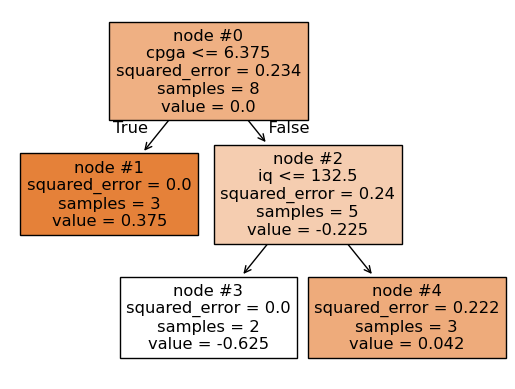

In [33]:
plot_tree(dt1, feature_names=['cpga', 'iq'], filled=True, node_ids=True);

### Find which leaf the point lies in

In [34]:
df['leaf_entry1'] = dt1.apply(df.iloc[:, 0:2])

In [35]:
df

,cgpa,iq,is_placed,pred1(log-odds),pred1(probability),res1,leaf_entry1
0,6.82,118,0,0.510826,0.625,-0.625,3
1,6.36,125,1,0.510826,0.625,0.375,1
2,5.39,99,1,0.510826,0.625,0.375,1
3,5.50,106,1,0.510826,0.625,0.375,1
4,6.39,148,0,0.510826,0.625,-0.625,4
5,9.13,148,1,0.510826,0.625,0.375,4
6,7.17,147,1,0.510826,0.625,0.375,4
7,7.72,72,0,0.510826,0.625,-0.625,3


### Calculate log-odds 

In [40]:
def calculate_odds(leaf):
    temp_df = df[df['leaf_entry1'] == leaf] # Find the points according to their leaf entries
    nr = temp_df['res1'].sum()
    dr = sum(temp_df['pred1(probability)'] * (1 - temp_df['pred1(probability)']))
    return (nr/dr)

In [41]:
df['pred2(log-odds)'] = df['pred1(log-odds)'] + df['leaf_entry1'].apply(calculate_odds)

In [42]:
df

,cgpa,iq,is_placed,pred1(log-odds),pred1(probability),res1,leaf_entry1,pred2(log-odds)
0,6.82,118,0,0.510826,0.625,-0.625,3,-2.155841
1,6.36,125,1,0.510826,0.625,0.375,1,2.110826
2,5.39,99,1,0.510826,0.625,0.375,1,2.110826
3,5.50,106,1,0.510826,0.625,0.375,1,2.110826
4,6.39,148,0,0.510826,0.625,-0.625,4,0.688603
5,9.13,148,1,0.510826,0.625,0.375,4,0.688603
6,7.17,147,1,0.510826,0.625,0.375,4,0.688603
7,7.72,72,0,0.510826,0.625,-0.625,3,-2.155841


### Convert log-odds to probability

In [45]:
df['pred2(probability)'] = 1 / (1 + np.exp(-df['pred2(log-odds)']))

In [46]:
df

,cgpa,iq,is_placed,pred1(log-odds),pred1(probability),res1,leaf_entry1,pred2(log-odds),pred2(probability)
0,6.82,118,0,0.510826,0.625,-0.625,3,-2.155841,0.103787
1,6.36,125,1,0.510826,0.625,0.375,1,2.110826,0.891951
2,5.39,99,1,0.510826,0.625,0.375,1,2.110826,0.891951
3,5.50,106,1,0.510826,0.625,0.375,1,2.110826,0.891951
4,6.39,148,0,0.510826,0.625,-0.625,4,0.688603,0.665656
5,9.13,148,1,0.510826,0.625,0.375,4,0.688603,0.665656
6,7.17,147,1,0.510826,0.625,0.375,4,0.688603,0.665656
7,7.72,72,0,0.510826,0.625,-0.625,3,-2.155841,0.103787


### Calculate residuals

In [47]:
df['res2'] = df['is_placed'] - df['pred2(probability)']

In [48]:
df

,cgpa,iq,is_placed,pred1(log-odds),pred1(probability),res1,leaf_entry1,pred2(log-odds),pred2(probability),res2
0,6.82,118,0,0.510826,0.625,-0.625,3,-2.155841,0.103787,-0.103787
1,6.36,125,1,0.510826,0.625,0.375,1,2.110826,0.891951,0.108049
2,5.39,99,1,0.510826,0.625,0.375,1,2.110826,0.891951,0.108049
3,5.50,106,1,0.510826,0.625,0.375,1,2.110826,0.891951,0.108049
4,6.39,148,0,0.510826,0.625,-0.625,4,0.688603,0.665656,-0.665656
5,9.13,148,1,0.510826,0.625,0.375,4,0.688603,0.665656,0.334344
6,7.17,147,1,0.510826,0.625,0.375,4,0.688603,0.665656,0.334344
7,7.72,72,0,0.510826,0.625,-0.625,3,-2.155841,0.103787,-0.103787


In [49]:
df[['res1', 'res2']]

,res1,res2
0,-0.625,-0.103787
1,0.375,0.108049
2,0.375,0.108049
3,0.375,0.108049
4,-0.625,-0.665656
5,0.375,0.334344
6,0.375,0.334344
7,-0.625,-0.103787


* See the decrease in the residuals and eventually these would become zero when we add more learners to the ensemble.